In [1]:
import os
import copy
import pickle
import sympy
import functools
import itertools
import math
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from error_injection import MissingValueError, SamplingError, Injector
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import SimpleImputer, KNNImputer, IterativeImputer
from sklearn.metrics import mutual_info_score, auc, roc_curve, roc_auc_score, f1_score
from scipy.optimize import minimize as scipy_min
from scipy.spatial import ConvexHull
from scipy.optimize import minimize, Bounds, linprog
from sympy import Symbol as sb
from sympy import lambdify
from tqdm.notebook import trange,tqdm
from IPython.display import display,clear_output
from random import choice
from sklearn.linear_model import LinearRegression
from sklearn.utils import resample
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import Ridge
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import _tree
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import make_scorer, recall_score
from itertools import combinations, product
import heapq
class style():
    RED = '\033[31m'
    GREEN = '\033[32m'
    BLUE = '\033[34m'
    RESET = '\033[0m'

np.random.seed(1)

# ignore all the warnings
import warnings
warnings.filterwarnings('ignore')

In [2]:
# first impute the data and make it hypothetically clean
def load_mpg_cleaned():
    # fetch dataset
    auto_mpg = pd.read_csv('auto-mpg.csv').drop('car name', axis=1).replace('?', np.nan)
    
    features = ['cylinders', 'displacement', 'horsepower', 'weight',
                'acceleration', 'model year', 'origin']
    X = auto_mpg[features].astype(float)
    y = auto_mpg['mpg']
    
    # assumed gt imputation
    imputer = KNNImputer(n_neighbors=10)
    X = pd.DataFrame(imputer.fit_transform(X), columns=X.columns)

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1)
    X_train = copy.deepcopy(X_train).reset_index(drop=True)
    X_test = copy.deepcopy(X_test).reset_index(drop=True)
    y_train = y_train.reset_index(drop=True)
    y_test = y_test.reset_index(drop=True)

    return X_train, X_test, y_train, y_test
X_train, X_test, y_train, y_test = load_mpg_cleaned()
print(X_train.shape)
X_train.head()

(318, 7)


,cylinders,displacement,horsepower,weight,acceleration,model year,origin
0,8.0,350.0,125.0,3900.0,17.4,79.0,1.0
1,8.0,455.0,225.0,3086.0,10.0,70.0,1.0
2,4.0,91.0,68.0,2025.0,18.2,82.0,3.0
3,4.0,122.0,86.0,2226.0,16.5,72.0,1.0
4,4.0,97.0,67.0,2065.0,17.8,81.0,3.0


In [4]:
X_train.columns

Index(['cylinders', 'displacement', 'horsepower', 'weight', 'acceleration',
       'model year', 'origin'],
      dtype='object')

In [5]:
X_train_transformed = X_train.copy()
X_test_transformed = X_test.copy()

columns_to_bin = ['displacement', 'horsepower', 'weight', 'acceleration']
n_bins = {'displacement': int(np.sqrt(72)), 'horsepower': int(np.sqrt(87)), 'weight': int(np.sqrt(288)), 'acceleration': int(np.sqrt(86))}
column_bins = {}

for col in columns_to_bin:
    # Apply binning (equal-width bins in this example)
    X_train_transformed[col], bins = pd.cut(
        X_train[col], 
        bins=n_bins[col], 
        labels=False, 
        retbins=True
    )

    X_test_transformed[col] = pd.cut(
        X_test[col],
        bins=bins,      # Use the same bins from X_train
        labels=False,   # Keep consistent labels
        include_lowest=True  # Ensure the lowest bin includes its boundary
    )

    X_train_transformed[col] = X_train_transformed[col].fillna(-1).astype(int)
    X_test_transformed[col] = X_test_transformed[col].fillna(-1).astype(int)

    column_bins[col] = bins

# Instructions
1. Initiate all cells above
2. Don't run any cells below except the "get_complex_candidate_target_indices" function
3. Run all cells and below starting from cell after "result" variable

In [14]:
def compute_optimized_candidates(X, tau, n_features_to_combine=2):

    candidates = []
    n_samples, n_features = X.shape
    
    # Generate combinations of features to combine
    feature_combinations = list(combinations(range(n_features), n_features_to_combine))
    
    for feature_combo in tqdm(feature_combinations, desc="Processing feature combinations"):
        # Get unique values for each feature in the combination
        values_list = [np.unique(X.iloc[:, idx]) for idx in feature_combo]
        
        # Iterate over all possible value-condition combinations
        for value_combo in tqdm(
            product(*values_list),
            desc=f"Processing combination {feature_combo}",
            leave=False
        ):
            for conditions in product(["<", "=", ">"], repeat=n_features_to_combine):
                # Skip conflicting combinations
                if has_conflicts(value_combo, conditions):
                    continue

                # Generate pattern
                pattern = np.ones(n_samples, dtype=bool)  # Start with all True
                for idx, (feat_idx, val, cond) in enumerate(zip(feature_combo, value_combo, conditions)):
                    if cond == "<":
                        pattern &= X.iloc[:, feat_idx] < val
                    elif cond == "=":
                        pattern &= X.iloc[:, feat_idx] == val
                    elif cond == ">":
                        pattern &= X.iloc[:, feat_idx] > val
                
                # Check support
                support = np.sum(pattern)
                if support <= (tau * n_samples) and support >= (0.5 * tau * n_samples):
                    candidates.append((feature_combo, value_combo, conditions))
    
    return candidates


def has_conflicts(value_combo, conditions):
    for i in range(len(value_combo)):
        for j in range(i + 1, len(value_combo)):
            # Detect conflicts like "< x AND > x" for the same value
            if conditions[i] == ">" and conditions[j] == "<" and value_combo[i] <= value_combo[j]:
                return True
            if conditions[i] == "<" and conditions[j] == ">" and value_combo[i] >= value_combo[j]:
                return True
            # Detect conflicts like "= x AND < x" or "= x AND > x"
            if conditions[i] == "=" and (conditions[j] == "<" and value_combo[i] >= value_combo[j]):
                return True
            if conditions[i] == "=" and (conditions[j] == ">" and value_combo[i] <= value_combo[j]):
                return True
            # Symmetry of conditions
            if conditions[j] == "=" and (conditions[i] == "<" and value_combo[j] >= value_combo[i]):
                return True
            if conditions[j] == "=" and (conditions[i] == ">" and value_combo[j] <= value_combo[i]):
                return True
    return False

In [16]:
candidates = compute_optimized_candidates(X_train_transformed, 0.1, n_features_to_combine=3)
len(candidates)

Processing feature combinations:   0%|          | 0/35 [00:00<?, ?it/s]

Processing combination (0, 1, 2): 0it [00:00, ?it/s]

Processing combination (0, 1, 3): 0it [00:00, ?it/s]

Processing combination (0, 1, 4): 0it [00:00, ?it/s]

Processing combination (0, 1, 5): 0it [00:00, ?it/s]

...

Processing combination (3, 4, 5): 0it [00:00, ?it/s]

Processing combination (3, 4, 6): 0it [00:00, ?it/s]

Processing combination (3, 5, 6): 0it [00:00, ?it/s]

Processing combination (4, 5, 6): 0it [00:00, ?it/s]

11060

In [17]:
def get_complex_candidate_target_indices(df, candidate):
    columns, values, conditions = candidate
    mask = pd.Series(True, index=df.index)  # Start with a mask that selects all rows

    for col, val, cond in zip(columns, values, conditions):
        if cond == "<":
            mask &= df.iloc[:, col] < val
        elif cond == "=":
            mask &= df.iloc[:, col] == val
        elif cond == ">":
            mask &= df.iloc[:, col] > val
        else:
            raise ValueError(f"Unsupported condition: {cond}")

    return df[mask].index.tolist()

In [18]:
def filter_dataframe_by_complex_candidate(df, labels, candidate):
    mask = get_complex_candidate_target_indices(df, candidate)

    return df[df.index.isin(mask) == False], labels[labels.index.isin(mask) == False]

In [20]:
def mse(y_true, y_pred):
    return sum((y_true - y_pred)**2)/len(y_true)

def mae(y_true, y_pred):
    return sum(abs(y_true - y_pred))/len(y_true)

lr = LinearRegression()

def mse_filter(candidates, X_train_transformed, X_test_transformed, y_train, y_test):

    top_candidates = []

    seen_mse = set()
    
    for candidate in tqdm(candidates, desc="Processing Candidates"):
        number_indices = len(get_complex_candidate_target_indices(X_train_transformed, candidate))
        filtered_X_train, filtered_y_train = filter_dataframe_by_complex_candidate(X_train_transformed, y_train, candidate)
        model = lr.fit(filtered_X_train, filtered_y_train)
        predictions = model.predict(X_test_transformed)
        new_mse = mse(predictions, y_test)
        #print(new_mae)

        if new_mse in seen_mse:
            continue
        
        seen_mse.add(new_mse)

        top_candidates = top_candidates + [(new_mse, candidate, number_indices)]
    top_candidates = sorted(top_candidates, key=lambda x: (x[0], -x[2]), reverse=True)[0:3000]
    return top_candidates

In [21]:
top_candidates = [x[1] for x in mse_filter(candidates, X_train_transformed, X_test_transformed, y_train, y_test)]
len(top_candidates)

Processing Candidates:   0%|          | 0/11060 [00:00<?, ?it/s]

3000

In [22]:
top_candidates[0:5]

[((0, 1, 3), (3.0, 0, 11), ('>', '>', '>')),
 ((0, 2, 3), (3.0, 4, 11), ('>', '>', '>')),
 ((0, 3, 4), (6.0, 11, 5), ('>', '>', '<')),
 ((0, 3, 4), (5.0, 11, 4), ('>', '>', '<')),
 ((0, 1, 3), (3.0, 4, 11), ('>', '>', '>'))]

In [23]:
def top_k_finder(candidates, X_transformed, X_train, y_train, X_test, y_test, k, tau, robustness_radius, uncertain_ratio):
    n_samples, n_features = X_train.shape

    seen_ratios = set()
    
    # Min-heap to store the top k worst robustness ratios
    top_k_patterns = []
    
    for candidate in tqdm(candidates, desc="Processing Candidates"):
        # Get indices satisfying the candidate pattern
        target_indices = get_complex_candidate_target_indices(X_transformed, candidate)
        
        # Compute robustness ratio
        robustness_ratio = compute_robustness_ratio_sensitive_label_error(
            X_train, y_train, X_test, y_test, 
            uncertain_num=int(tau * len(y_train)),
            boundary_indices=target_indices,
            uncertain_radius=uncertain_ratio * (y_train.max() - y_train.min()), 
            robustness_radius=robustness_radius, 
            interval=False
        )

        if robustness_ratio in seen_ratios:
            continue

        seen_ratios.add(robustness_ratio)
        
        print(robustness_ratio)
        
        top_k_patterns = top_k_patterns + [(robustness_ratio, candidate)]
        
    return sorted(top_k_patterns, key=lambda x: x[0])[0:k]

In [24]:
result = top_k_finder(top_candidates, X_train_transformed, X_train, y_train, X_test, y_test, 3, 0.1, 2, 0.25)

Processing Candidates:   0%|          | 0/3000 [00:00<?, ?it/s]

0.5125
0.6375
0.5625
0.675
0.6
0.6875
0.7
0.75
0.5875
0.625
0.775
0.6625
0.7625
0.7125
0.8
0.7875
0.8625
0.8375
0.825
0.8875
0.85
0.8125
0.9
0.55
0.525
0.6125
0.5375
0.725
0.875
0.7375
0.575
0.65
0.9125
0.9625
0.975
0.925
0.9375
1.0
0.475
0.9875
0.95
0.5
0.4375
0.4875
0.4
0.4625
0.4125
0.425
0.3625
0.45
0.3875


In [25]:
result

[(0.3625, ((3, 4, 5), (9, 3, 82.0), ('<', '<', '<'))),
 (0.3875, ((1, 2, 4), (6, 5, 3), ('<', '<', '<'))),
 (0.4, ((3, 4, 5), (11, 3, 72.0), ('<', '<', '>')))]

Result:

[(0.3625, ((3, 4, 5), (9, 3, 82.0), ('<', '<', '<'))),
 (0.3875, ((1, 2, 4), (6, 5, 3), ('<', '<', '<'))),
 (0.4, ((3, 4, 5), (11, 3, 72.0), ('<', '<', '>')))]

In [30]:
pattern1 =  ((3, 4, 5), (9, 3, 82.0), ('<', '<', '<'))
pattern2 = ((1, 2, 4), (6, 5, 3), ('<', '<', '<'))
pattern3 = ((3, 4, 5), (11, 3, 72.0), ('<', '<', '>'))

target_indices_of_pattern1 = get_complex_candidate_target_indices(X_train_transformed, pattern1)
target_indices_of_pattern2 = get_complex_candidate_target_indices(X_train_transformed, pattern2)
target_indices_of_pattern3 = get_complex_candidate_target_indices(X_train_transformed, pattern3)

In [34]:
column_bins

{'displacement': array([ 69.615, 118.125, 166.25 , 214.375, 262.5  , 310.625, 358.75 ,
        406.875, 455.   ]),
 'horsepower': array([ 45.816     ,  66.44444444,  86.88888889, 107.33333333,
        127.77777778, 148.22222222, 168.66666667, 189.11111111,
        209.55555556, 230.        ]),
 'weight': array([1609.473 , 1833.4375, 2053.875 , 2274.3125, 2494.75  , 2715.1875,
        2935.625 , 3156.0625, 3376.5   , 3596.9375, 3817.375 , 4037.8125,
        4258.25  , 4478.6875, 4699.125 , 4919.5625, 5140.    ]),
 'acceleration': array([ 8.4837    , 10.31111111, 12.12222222, 13.93333333, 15.74444444,
        17.55555556, 19.36666667, 21.17777778, 22.98888889, 24.8       ])}

In [37]:
cols

Index(['cylinders', 'displacement', 'horsepower', 'weight', 'acceleration',
       'model year', 'origin'],
      dtype='object')

In [38]:
cols = X_train.columns
print("Pattern 1:")
for i in range(0, len(pattern1[0])):
    target_column = cols[pattern1[0][i]]
    val = pattern1[1][i]
    condition = pattern1[2][i]
    if target_column in column_bins:
        binnings = column_bins[target_column]
        if condition == '>':
            val = binnings[val]
            print(f"'{target_column}' {condition} {val}")
        elif condition == '<':
            val = binnings[val - 1]
            print(f"'{target_column}' {condition} {val}")
        else:
            lower_val = binnings[val - 1]
            upper_val = binnings[val]
            print(f"{lower_val} < '{target_column}' < {upper_val}")
    else:
        print(f"'{target_column}' {condition} {val}")
print()
print("Pattern 2:")
for i in range(0, len(pattern2[0])):
    target_column = cols[pattern2[0][i]]
    val = pattern2[1][i]
    condition = pattern2[2][i]
    if target_column in column_bins:
        binnings = column_bins[target_column]
        if condition == '>':
            val = binnings[val]
            print(f"'{target_column}' {condition} {val}")
        elif condition == '<':
            val = binnings[val - 1]
            print(f"'{target_column}' {condition} {val}")
        else:
            lower_val = binnings[val - 1]
            upper_val = binnings[val]
            print(f"{lower_val} < '{target_column}' < {upper_val}")
    else:
        print(f"'{target_column}' {condition} {val}")
print()
print("Pattern 3:")
for i in range(0, len(pattern3[0])):
    target_column = cols[pattern3[0][i]]
    val = pattern3[1][i]
    condition = pattern3[2][i]
    if target_column in column_bins:
        binnings = column_bins[target_column]
        if condition == '>':
            val = binnings[val]
            print(f"'{target_column}' {condition} {val}")
        elif condition == '<':
            val = binnings[val - 1]
            print(f"'{target_column}' {condition} {val}")
        else:
            lower_val = binnings[val - 1]
            upper_val = binnings[val]
            print(f"{lower_val} < '{target_column}' < {upper_val}")
    else:
        print(f"'{target_column}' {condition} {val}")

Pattern 1:
'weight' < 3376.5
'acceleration' < 12.122222222222222
'model year' < 82.0

Pattern 2:
'displacement' < 310.625
'horsepower' < 127.77777777777777
'acceleration' < 12.122222222222222

Pattern 3:
'weight' < 3817.375
'acceleration' < 12.122222222222222
'model year' > 72.0


In [39]:
#Useful functions
symbol_id = -1
def create_symbol(suffix=''):
    global symbol_id
    symbol_id += 1
    name = f'e{symbol_id}_{suffix}' if suffix else f'e{symbol_id}'
    return sympy.Symbol(name=name)


scaler_symbols = set([sb(f'k{i}') for i in range(X_train.shape[1]+1)])
linearization_dict = dict()
reverse_linearization_dict = dict()

def inject_sensitive_ranges(X, y, uncertain_attr, uncertain_num, boundary_indices, uncertain_radius_pct=None, 
                  uncertain_radius=None, seed=42):
    global symbol_id
    symbol_id = -1
    
    X_extended = np.append(np.ones((len(X), 1)), X, axis=1)
    ss = StandardScaler()
    X_extended[:, 1:] = ss.fit_transform(X_extended[:, 1:])
    X_extended_symb = sympy.Matrix(X_extended)
    
    if not(uncertain_attr=='y'):
        uncertain_attr_idx = X.columns.to_list().index(uncertain_attr) + 1
        if not(uncertain_radius):
            uncertain_radius = uncertain_radius_pct*(np.max(X_extended[:, uncertain_attr_idx])-\
                                                     np.min(X_extended[:, uncertain_attr_idx]))
    else:
        if not(uncertain_radius):
            uncertain_radius = uncertain_radius_pct*(y_train.max()-y_train.min())[0]
    
    np.random.seed(seed)
    uncertain_indices = boundary_indices[:uncertain_num]
    y_symb = sympy.Matrix(y)
    symbols_in_data = set()
    #print(uncertain_indices)
    for uncertain_idx in uncertain_indices:
        new_symb = create_symbol()
        symbols_in_data.add(new_symb)
        if uncertain_attr=='y':
            y_symb[uncertain_idx] = y_symb[uncertain_idx] + uncertain_radius*new_symb
        else:
            X_extended_symb[uncertain_idx, uncertain_attr_idx] = X_extended_symb[uncertain_idx, uncertain_attr_idx] + uncertain_radius*new_symb
    return X_extended_symb, y_symb, symbols_in_data, ss

# if interval=True, use interval arithmetic, otherwise use zonotopes
def compute_robustness_ratio_sensitive_label_error(X_train, y_train, X_test, y_test, robustness_radius,
                                         uncertain_num, boundary_indices, uncertain_radius=None, 
                                         lr=0.1, seed=42, interval=True):
    X, y, symbols_in_data, ss = inject_sensitive_ranges(X=X_train, y=y_train, uncertain_attr='y', 
                                              uncertain_num=uncertain_num, boundary_indices=boundary_indices, 
                                              uncertain_radius=uncertain_radius, 
                                              uncertain_radius_pct=None, seed=seed)
    
    assert len(X.free_symbols)==0
    # closed-form
    param = (X.T*X).inv()*X.T*y
    
    if interval:
        # make param intervals
        for d in range(len(param)):
            expr = param[d]
            if not(expr.free_symbols):
                continue
            else:
                constant_part = 0
                interval_radius = 0
                for arg in expr.args:
                    if arg.free_symbols:
                        interval_radius += abs(arg.args[0])
                    else:
                        assert constant_part == 0
                        constant_part = arg
                param[d] = constant_part + create_symbol()*interval_radius
    
    test_preds = sympy.Matrix(np.append(np.ones((len(X_test), 1)), ss.transform(X_test), axis=1))*param
    robustness_ls = []
    for pred in test_preds:
        pred_range_radius = 0
        for arg in pred.args:
            if arg.free_symbols:
                pred_range_radius += abs(arg.args[0])
        if pred_range_radius <= robustness_radius:
            robustness_ls.append(1)
        else:
            robustness_ls.append(0)
    
#     print(param)
    return np.mean(robustness_ls)

def inject_ranges(X, y, uncertain_attr, uncertain_num, uncertain_radius_pct=None, uncertain_radius=None, seed=42):
    global symbol_id
    symbol_id = -1
    
    X_extended = np.append(np.ones((len(X), 1)), X, axis=1)
    ss = StandardScaler()
    X_extended[:, 1:] = ss.fit_transform(X_extended[:, 1:])
    X_extended_symb = sympy.Matrix(X_extended)
    
    if not(uncertain_attr=='y'):
        uncertain_attr_idx = X.columns.to_list().index(uncertain_attr) + 1
        if not(uncertain_radius):
            uncertain_radius = uncertain_radius_pct*(np.max(X_extended[:, uncertain_attr_idx])-\
                                                     np.min(X_extended[:, uncertain_attr_idx]))
    else:
        if not(uncertain_radius):
            uncertain_radius = uncertain_radius_pct*(y_train.max()-y_train.min())[0]
    
    np.random.seed(seed)
    uncertain_indices = np.random.choice(range(len(y)), uncertain_num, replace=False)
    y_symb = sympy.Matrix(y)
    symbols_in_data = set()
    for uncertain_idx in uncertain_indices:
        new_symb = create_symbol()
        symbols_in_data.add(new_symb)
        if uncertain_attr=='y':
            y_symb[uncertain_idx] = y_symb[uncertain_idx] + uncertain_radius*new_symb
        else:
            X_extended_symb[uncertain_idx, uncertain_attr_idx] = X_extended_symb[uncertain_idx, uncertain_attr_idx] + uncertain_radius*new_symb
    return X_extended_symb, y_symb, symbols_in_data, ss

# if interval=True, use interval arithmetic, otherwise use zonotopes
def compute_robustness_ratio_label_error(X_train, y_train, X_test, y_test, robustness_radius,
                                         uncertain_num, uncertain_radius=None, 
                                         lr=0.1, seed=42, interval=True):
    X, y, symbols_in_data, ss = inject_ranges(X=X_train, y=y_train, uncertain_attr='y', 
                                              uncertain_num=uncertain_num, uncertain_radius=uncertain_radius, 
                                              uncertain_radius_pct=None, seed=seed)
    
    assert len(X.free_symbols)==0
    # closed-form
    param = (X.T*X).inv()*X.T*y
    
    if interval:
        # make param intervals
        for d in range(len(param)):
            expr = param[d]
            if not(expr.free_symbols):
                continue
            else:
                constant_part = 0
                interval_radius = 0
                for arg in expr.args:
                    if arg.free_symbols:
                        interval_radius += abs(arg.args[0])
                    else:
                        assert constant_part == 0
                        constant_part = arg
                param[d] = constant_part + create_symbol()*interval_radius
    
    test_preds = sympy.Matrix(np.append(np.ones((len(X_test), 1)), ss.transform(X_test), axis=1))*param
    robustness_ls = []
    for pred in test_preds:
        pred_range_radius = 0
        for arg in pred.args:
            if arg.free_symbols:
                pred_range_radius += abs(arg.args[0])
        if pred_range_radius <= robustness_radius:
            robustness_ls.append(1)
        else:
            robustness_ls.append(0)
    
#     print(param)
    return np.mean(robustness_ls)

In [40]:
# pattern1_testing (Meyer)
robustness_dicts_interval_pattern1 = []
for seed in range(1):
    # mpg +- 2 is robust
    robustness_radius = 2
    label_range = (y_train.max()-y_train.min())
    ratios = [0.05, 0.10, 0.15, 0.2, 0.25]
    uncertain_radiuses = [ratio*label_range for ratio in ratios]
    uncertain_pcts = list(np.arange(1, 11)/100)
    robustness_dict_interval = dict()
    robustness_dict_interval['uncertain_radius'] = uncertain_radiuses
    robustness_dict_interval['uncertain_radius_ratios'] = ratios
    for uncertain_pct in tqdm(uncertain_pcts, desc='Progess'):
        robustness_dict_interval[uncertain_pct] = list()
        uncertain_num = int(uncertain_pct*len(y_train))
        for uncertain_radius in tqdm(uncertain_radiuses, desc=f'Varying Uncertain Radius'):
            robustness_ratio = compute_robustness_ratio_sensitive_label_error(X_train, y_train, X_test, y_test, 
                                                                    uncertain_num=uncertain_num,
                                                                    boundary_indices=target_indices_of_pattern1,
                                                                    uncertain_radius=uncertain_radius, 
                                                                    robustness_radius=robustness_radius, 
                                                                    interval=True, seed=seed)
            robustness_dict_interval[uncertain_pct].append(robustness_ratio)
    robustness_dicts_interval_pattern1.append(robustness_dict_interval)

Progess:   0%|          | 0/10 [00:00<?, ?it/s]

Varying Uncertain Radius:   0%|          | 0/5 [00:00<?, ?it/s]

Varying Uncertain Radius:   0%|          | 0/5 [00:00<?, ?it/s]

Varying Uncertain Radius:   0%|          | 0/5 [00:00<?, ?it/s]

Varying Uncertain Radius:   0%|          | 0/5 [00:00<?, ?it/s]

...

Varying Uncertain Radius:   0%|          | 0/5 [00:00<?, ?it/s]

Varying Uncertain Radius:   0%|          | 0/5 [00:00<?, ?it/s]

Varying Uncertain Radius:   0%|          | 0/5 [00:00<?, ?it/s]

Varying Uncertain Radius:   0%|          | 0/5 [00:00<?, ?it/s]

Varying Uncertain Radius:   0%|          | 0/5 [00:00<?, ?it/s]

In [41]:
# pattern1_testing (Zorro)
robustness_dicts_pattern1 = []
for seed in range(1):
    # mpg +- 2 is robust
    robustness_radius = 2
    label_range = (y_train.max()-y_train.min())
    ratios = [0.05, 0.10, 0.15, 0.2, 0.25]
    uncertain_radiuses = [ratio*label_range for ratio in ratios]
    uncertain_pcts = list(np.arange(1, 11)/100)
    robustness_dict = dict()
    robustness_dict['uncertain_radius'] = uncertain_radiuses
    robustness_dict['uncertain_radius_ratios'] = ratios
    for uncertain_pct in tqdm(uncertain_pcts, desc='Progess'):
        robustness_dict[uncertain_pct] = list()
        uncertain_num = int(uncertain_pct*len(y_train))
        for uncertain_radius in tqdm(uncertain_radiuses, desc=f'Varying Uncertain Radius'):
            #print(uncertain_radius)
            robustness_ratio = compute_robustness_ratio_sensitive_label_error(X_train, y_train, X_test, y_test, 
                                                                    uncertain_num=uncertain_num,
                                                                    boundary_indices=target_indices_of_pattern1,
                                                                    uncertain_radius=uncertain_radius, 
                                                                    robustness_radius=robustness_radius, 
                                                                    interval=False, seed=seed)
            robustness_dict[uncertain_pct].append(robustness_ratio)
    robustness_dicts_pattern1.append(robustness_dict)

Progess:   0%|          | 0/10 [00:00<?, ?it/s]

Varying Uncertain Radius:   0%|          | 0/5 [00:00<?, ?it/s]

Varying Uncertain Radius:   0%|          | 0/5 [00:00<?, ?it/s]

Varying Uncertain Radius:   0%|          | 0/5 [00:00<?, ?it/s]

Varying Uncertain Radius:   0%|          | 0/5 [00:00<?, ?it/s]

...

Varying Uncertain Radius:   0%|          | 0/5 [00:00<?, ?it/s]

Varying Uncertain Radius:   0%|          | 0/5 [00:00<?, ?it/s]

Varying Uncertain Radius:   0%|          | 0/5 [00:00<?, ?it/s]

Varying Uncertain Radius:   0%|          | 0/5 [00:00<?, ?it/s]

Varying Uncertain Radius:   0%|          | 0/5 [00:00<?, ?it/s]

In [42]:
# pattern2_testing (Meyer)
robustness_dicts_interval_pattern2 = []
for seed in range(1):
    # mpg +- 2 is robust
    robustness_radius = 2
    label_range = (y_train.max()-y_train.min())
    ratios = [0.05, 0.10, 0.15, 0.2, 0.25]
    uncertain_radiuses = [ratio*label_range for ratio in ratios]
    uncertain_pcts = list(np.arange(1, 11)/100)
    robustness_dict_interval = dict()
    robustness_dict_interval['uncertain_radius'] = uncertain_radiuses
    robustness_dict_interval['uncertain_radius_ratios'] = ratios
    for uncertain_pct in tqdm(uncertain_pcts, desc='Progess'):
        robustness_dict_interval[uncertain_pct] = list()
        uncertain_num = int(uncertain_pct*len(y_train))
        for uncertain_radius in tqdm(uncertain_radiuses, desc=f'Varying Uncertain Radius'):
            robustness_ratio = compute_robustness_ratio_sensitive_label_error(X_train, y_train, X_test, y_test, 
                                                                    uncertain_num=uncertain_num,
                                                                    boundary_indices=target_indices_of_pattern2,
                                                                    uncertain_radius=uncertain_radius, 
                                                                    robustness_radius=robustness_radius, 
                                                                    interval=True, seed=seed)
            robustness_dict_interval[uncertain_pct].append(robustness_ratio)
    robustness_dicts_interval_pattern2.append(robustness_dict_interval)

Progess:   0%|          | 0/10 [00:00<?, ?it/s]

Varying Uncertain Radius:   0%|          | 0/5 [00:00<?, ?it/s]

Varying Uncertain Radius:   0%|          | 0/5 [00:00<?, ?it/s]

Varying Uncertain Radius:   0%|          | 0/5 [00:00<?, ?it/s]

Varying Uncertain Radius:   0%|          | 0/5 [00:00<?, ?it/s]

...

Varying Uncertain Radius:   0%|          | 0/5 [00:00<?, ?it/s]

Varying Uncertain Radius:   0%|          | 0/5 [00:00<?, ?it/s]

Varying Uncertain Radius:   0%|          | 0/5 [00:00<?, ?it/s]

Varying Uncertain Radius:   0%|          | 0/5 [00:00<?, ?it/s]

Varying Uncertain Radius:   0%|          | 0/5 [00:00<?, ?it/s]

In [43]:
# pattern2_testing (Zorro)
robustness_dicts_pattern2 = []
for seed in range(1):
    # mpg +- 2 is robust
    robustness_radius = 2
    label_range = (y_train.max()-y_train.min())
    ratios = [0.05, 0.10, 0.15, 0.2, 0.25]
    uncertain_radiuses = [ratio*label_range for ratio in ratios]
    uncertain_pcts = list(np.arange(1, 11)/100)
    robustness_dict = dict()
    robustness_dict['uncertain_radius'] = uncertain_radiuses
    robustness_dict['uncertain_radius_ratios'] = ratios
    for uncertain_pct in tqdm(uncertain_pcts, desc='Progess'):
        robustness_dict[uncertain_pct] = list()
        uncertain_num = int(uncertain_pct*len(y_train))
        for uncertain_radius in tqdm(uncertain_radiuses, desc=f'Varying Uncertain Radius'):
            #print(uncertain_radius)
            robustness_ratio = compute_robustness_ratio_sensitive_label_error(X_train, y_train, X_test, y_test, 
                                                                    uncertain_num=uncertain_num,
                                                                    boundary_indices=target_indices_of_pattern2,
                                                                    uncertain_radius=uncertain_radius, 
                                                                    robustness_radius=robustness_radius, 
                                                                    interval=False, seed=seed)
            robustness_dict[uncertain_pct].append(robustness_ratio)
    robustness_dicts_pattern2.append(robustness_dict)

Progess:   0%|          | 0/10 [00:00<?, ?it/s]

Varying Uncertain Radius:   0%|          | 0/5 [00:00<?, ?it/s]

Varying Uncertain Radius:   0%|          | 0/5 [00:00<?, ?it/s]

Varying Uncertain Radius:   0%|          | 0/5 [00:00<?, ?it/s]

Varying Uncertain Radius:   0%|          | 0/5 [00:00<?, ?it/s]

...

Varying Uncertain Radius:   0%|          | 0/5 [00:00<?, ?it/s]

Varying Uncertain Radius:   0%|          | 0/5 [00:00<?, ?it/s]

Varying Uncertain Radius:   0%|          | 0/5 [00:00<?, ?it/s]

Varying Uncertain Radius:   0%|          | 0/5 [00:00<?, ?it/s]

Varying Uncertain Radius:   0%|          | 0/5 [00:00<?, ?it/s]

In [44]:
# pattern3_testing (Meyer)
robustness_dicts_interval_pattern3 = []
for seed in range(1):
    # mpg +- 2 is robust
    robustness_radius = 2
    label_range = (y_train.max()-y_train.min())
    ratios = [0.05, 0.10, 0.15, 0.2, 0.25]
    uncertain_radiuses = [ratio*label_range for ratio in ratios]
    uncertain_pcts = list(np.arange(1, 11)/100)
    robustness_dict_interval = dict()
    robustness_dict_interval['uncertain_radius'] = uncertain_radiuses
    robustness_dict_interval['uncertain_radius_ratios'] = ratios
    for uncertain_pct in tqdm(uncertain_pcts, desc='Progess'):
        robustness_dict_interval[uncertain_pct] = list()
        uncertain_num = int(uncertain_pct*len(y_train))
        for uncertain_radius in tqdm(uncertain_radiuses, desc=f'Varying Uncertain Radius'):
            robustness_ratio = compute_robustness_ratio_sensitive_label_error(X_train, y_train, X_test, y_test, 
                                                                    uncertain_num=uncertain_num,
                                                                    boundary_indices=target_indices_of_pattern3,
                                                                    uncertain_radius=uncertain_radius, 
                                                                    robustness_radius=robustness_radius, 
                                                                    interval=True, seed=seed)
            robustness_dict_interval[uncertain_pct].append(robustness_ratio)
    robustness_dicts_interval_pattern3.append(robustness_dict_interval)

Progess:   0%|          | 0/10 [00:00<?, ?it/s]

Varying Uncertain Radius:   0%|          | 0/5 [00:00<?, ?it/s]

Varying Uncertain Radius:   0%|          | 0/5 [00:00<?, ?it/s]

Varying Uncertain Radius:   0%|          | 0/5 [00:00<?, ?it/s]

Varying Uncertain Radius:   0%|          | 0/5 [00:00<?, ?it/s]

...

Varying Uncertain Radius:   0%|          | 0/5 [00:00<?, ?it/s]

Varying Uncertain Radius:   0%|          | 0/5 [00:00<?, ?it/s]

Varying Uncertain Radius:   0%|          | 0/5 [00:00<?, ?it/s]

Varying Uncertain Radius:   0%|          | 0/5 [00:00<?, ?it/s]

Varying Uncertain Radius:   0%|          | 0/5 [00:00<?, ?it/s]

In [45]:
# pattern3_testing (Zorro)
robustness_dicts_pattern3 = []
for seed in range(1):
    # mpg +- 2 is robust
    robustness_radius = 2
    label_range = (y_train.max()-y_train.min())
    ratios = [0.05, 0.10, 0.15, 0.2, 0.25]
    uncertain_radiuses = [ratio*label_range for ratio in ratios]
    uncertain_pcts = list(np.arange(1, 11)/100)
    robustness_dict = dict()
    robustness_dict['uncertain_radius'] = uncertain_radiuses
    robustness_dict['uncertain_radius_ratios'] = ratios
    for uncertain_pct in tqdm(uncertain_pcts, desc='Progess'):
        robustness_dict[uncertain_pct] = list()
        uncertain_num = int(uncertain_pct*len(y_train))
        for uncertain_radius in tqdm(uncertain_radiuses, desc=f'Varying Uncertain Radius'):
            #print(uncertain_radius)
            robustness_ratio = compute_robustness_ratio_sensitive_label_error(X_train, y_train, X_test, y_test, 
                                                                    uncertain_num=uncertain_num,
                                                                    boundary_indices=target_indices_of_pattern3,
                                                                    uncertain_radius=uncertain_radius, 
                                                                    robustness_radius=robustness_radius, 
                                                                    interval=False, seed=seed)
            robustness_dict[uncertain_pct].append(robustness_ratio)
    robustness_dicts_pattern3.append(robustness_dict)

Progess:   0%|          | 0/10 [00:00<?, ?it/s]

Varying Uncertain Radius:   0%|          | 0/5 [00:00<?, ?it/s]

Varying Uncertain Radius:   0%|          | 0/5 [00:00<?, ?it/s]

Varying Uncertain Radius:   0%|          | 0/5 [00:00<?, ?it/s]

Varying Uncertain Radius:   0%|          | 0/5 [00:00<?, ?it/s]

...

Varying Uncertain Radius:   0%|          | 0/5 [00:00<?, ?it/s]

Varying Uncertain Radius:   0%|          | 0/5 [00:00<?, ?it/s]

Varying Uncertain Radius:   0%|          | 0/5 [00:00<?, ?it/s]

Varying Uncertain Radius:   0%|          | 0/5 [00:00<?, ?it/s]

Varying Uncertain Radius:   0%|          | 0/5 [00:00<?, ?it/s]

In [46]:
robustness_dicts_naive = []
for seed in tqdm(range(5), desc=f'Progress'):
    robustness_radius = 2
    label_range = (y_train.max()-y_train.min())
    ratios = [0.05, 0.10, 0.15, 0.2, 0.25]
    uncertain_radiuses = [ratio*label_range for ratio in ratios]
    uncertain_pcts = list(np.arange(1, 11)/100)
    robustness_dict = dict()
    robustness_dict['uncertain_radius'] = uncertain_radiuses
    robustness_dict['uncertain_radius_ratios'] = ratios
    for uncertain_pct in tqdm(uncertain_pcts, desc=f'Rep {seed+1}', leave=False):
        robustness_dict[uncertain_pct] = list()
        uncertain_num = int(uncertain_pct*len(y_train))
        for uncertain_radius in tqdm(uncertain_radiuses, desc=f'Varying Uncertain Radius', leave=False):
            robustness_ratio = compute_robustness_ratio_label_error(X_train, y_train, X_test, y_test, 
                                                                    uncertain_num=uncertain_num, 
                                                                    uncertain_radius=uncertain_radius, 
                                                                    robustness_radius=robustness_radius, 
                                                                    interval=False, seed=seed)
            robustness_dict[uncertain_pct].append(robustness_ratio)
    robustness_dicts_naive.append(robustness_dict)

Progress:   0%|          | 0/5 [00:00<?, ?it/s]

Rep 1:   0%|          | 0/10 [00:00<?, ?it/s]

Varying Uncertain Radius:   0%|          | 0/5 [00:00<?, ?it/s]

Varying Uncertain Radius:   0%|          | 0/5 [00:00<?, ?it/s]

Varying Uncertain Radius:   0%|          | 0/5 [00:00<?, ?it/s]

...

Varying Uncertain Radius:   0%|          | 0/5 [00:00<?, ?it/s]

Varying Uncertain Radius:   0%|          | 0/5 [00:00<?, ?it/s]

Varying Uncertain Radius:   0%|          | 0/5 [00:00<?, ?it/s]

Varying Uncertain Radius:   0%|          | 0/5 [00:00<?, ?it/s]

Varying Uncertain Radius:   0%|          | 0/5 [00:00<?, ?it/s]

In [47]:
robustness_dicts_interval_naive = []
for seed in tqdm(range(5), desc=f'Progress'):
    # mpg +- 2 is robust
    robustness_radius = 2
    label_range = (y_train.max()-y_train.min())
    ratios = [0.05, 0.10, 0.15, 0.2, 0.25]
    uncertain_radiuses = [ratio*label_range for ratio in ratios]
    uncertain_pcts = list(np.arange(1, 11)/100)
    robustness_dict_interval = dict()
    robustness_dict_interval['uncertain_radius'] = uncertain_radiuses
    robustness_dict_interval['uncertain_radius_ratios'] = ratios
    for uncertain_pct in tqdm(uncertain_pcts, desc=f'Rep {seed+1}', leave=False):
        robustness_dict_interval[uncertain_pct] = list()
        uncertain_num = int(uncertain_pct*len(y_train))
        for uncertain_radius in tqdm(uncertain_radiuses, desc=f'Varying Uncertain Radius', leave=False):
            robustness_ratio = compute_robustness_ratio_label_error(X_train, y_train, X_test, y_test, 
                                                                    uncertain_num=uncertain_num, 
                                                                    uncertain_radius=uncertain_radius, 
                                                                    robustness_radius=robustness_radius, 
                                                                    interval=True, seed=seed)
            robustness_dict_interval[uncertain_pct].append(robustness_ratio)
    robustness_dicts_interval_naive.append(robustness_dict_interval)

Progress:   0%|          | 0/5 [00:00<?, ?it/s]

Rep 1:   0%|          | 0/10 [00:00<?, ?it/s]

Varying Uncertain Radius:   0%|          | 0/5 [00:00<?, ?it/s]

Varying Uncertain Radius:   0%|          | 0/5 [00:00<?, ?it/s]

Varying Uncertain Radius:   0%|          | 0/5 [00:00<?, ?it/s]

...

Varying Uncertain Radius:   0%|          | 0/5 [00:00<?, ?it/s]

Varying Uncertain Radius:   0%|          | 0/5 [00:00<?, ?it/s]

Varying Uncertain Radius:   0%|          | 0/5 [00:00<?, ?it/s]

Varying Uncertain Radius:   0%|          | 0/5 [00:00<?, ?it/s]

Varying Uncertain Radius:   0%|          | 0/5 [00:00<?, ?it/s]

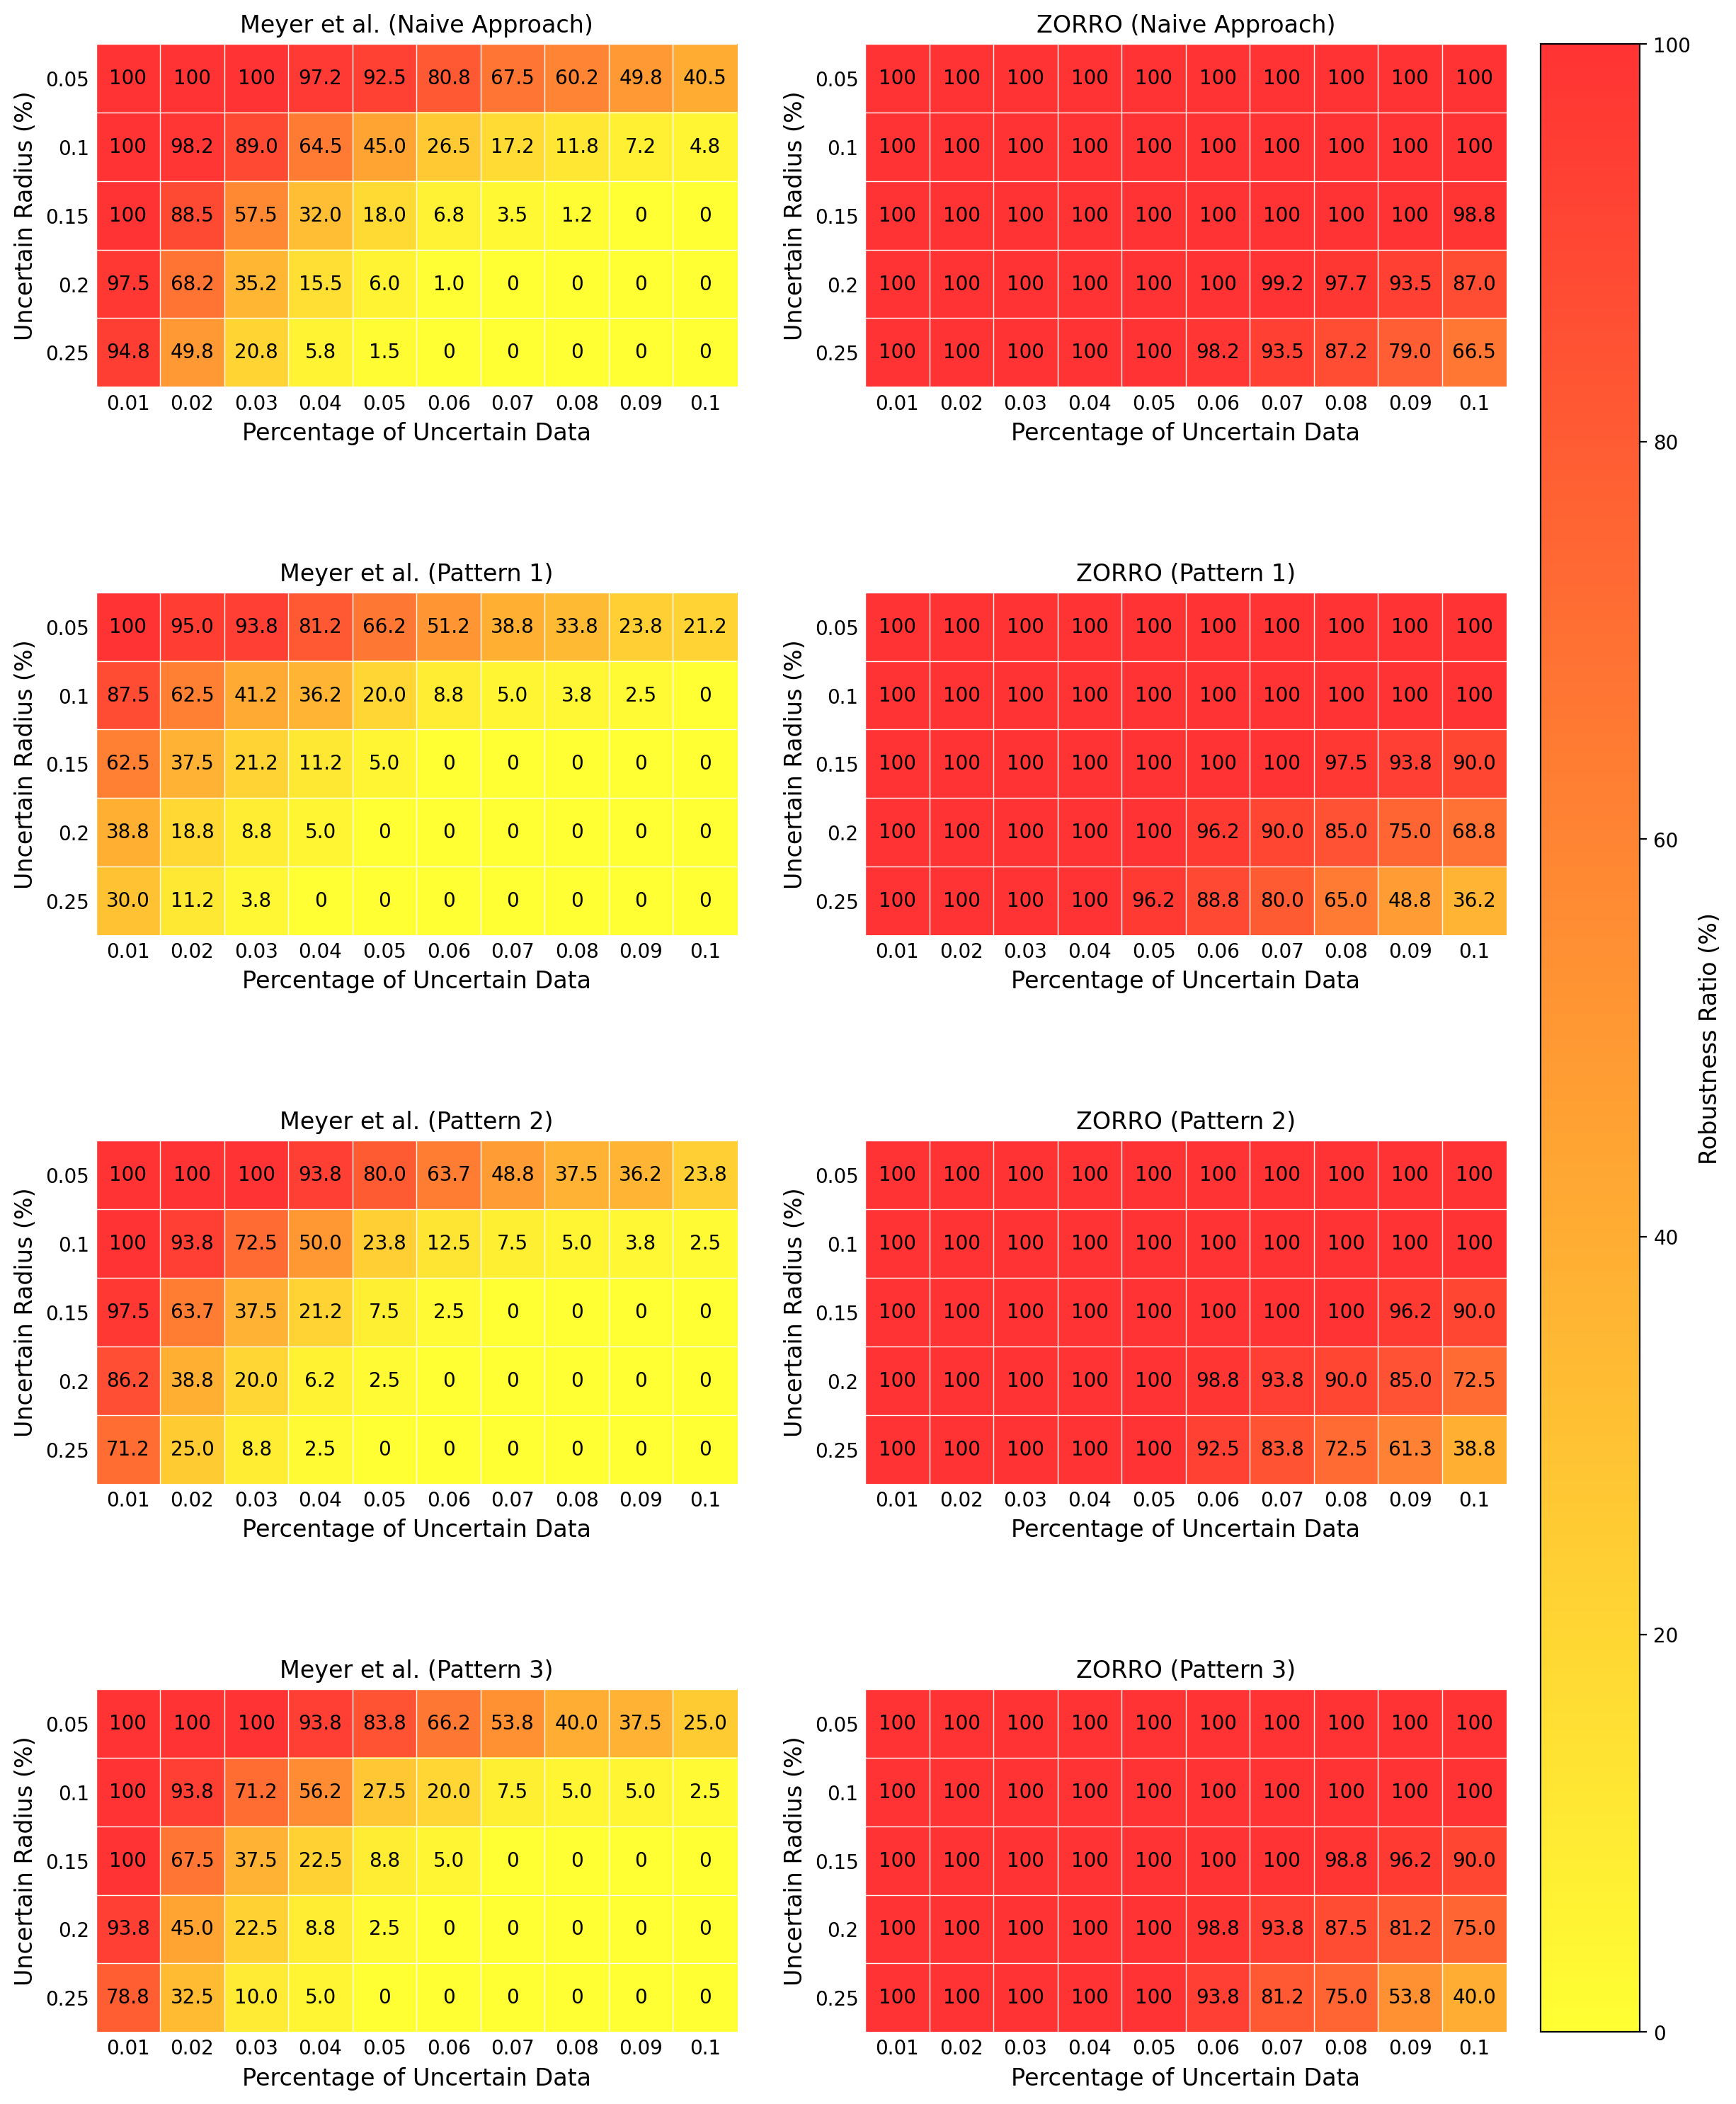

In [48]:
# Create the heatmap plot with a 2x2 grid
fig, axes = plt.subplots(4, 2, figsize=(15, 18), dpi=200)

# Define colormap
cmap = plt.get_cmap("autumn_r")

# Function to plot a single heatmap
def plot_heatmap(ax, heatmap_data, x_labels, y_labels, title):
    heatmap = ax.imshow(heatmap_data, cmap=cmap, interpolation='nearest', 
                        aspect='auto', alpha=0.8, vmin=0, vmax=100)
    ax.set_xticks(np.arange(len(x_labels)))
    ax.set_yticks(np.arange(len(y_labels)))
    ax.set_xticklabels(x_labels)
    ax.set_yticklabels(y_labels)
    ax.tick_params(axis='both', which='both', length=0)  # Remove tick marks
    
    # Add white lines by adjusting the linewidth for minor ticks
    ax.set_xticks(np.arange(len(x_labels)) - 0.5, minor=True)
    ax.set_yticks(np.arange(len(y_labels)) - 0.5, minor=True)
    ax.grid(which="minor", color="white", linestyle='-', linewidth=0.5)
    ax.tick_params(which="minor", size=0)
    
    # Remove external boundaries
    for spine in ax.spines.values():
        spine.set_visible(False)

    # Add text annotations
    for i in range(len(y_labels)):
        for j in range(len(x_labels)):
            if heatmap_data[i][j] == 100:
                text = ax.text(j, i, '100', ha='center', va='center', color='black')
            elif heatmap_data[i][j] == 0:
                text = ax.text(j, i, '0', ha='center', va='center', color='black')
            else:
                text = ax.text(j, i, f'{heatmap_data[i][j]:.1f}', ha='center', va='center', color='black')

    ax.set_title(title, fontsize=12)
    ax.set_xlabel('Percentage of Uncertain Data', fontsize=12)
    ax.set_ylabel('Uncertain Radius (%)', fontsize=12)

# Data for the heatmaps

#naive
df1 = sum([pd.DataFrame(robustness_dicts_interval_naive[i]).iloc[:, 2:] for i in range(5)])/5
df2 = sum([pd.DataFrame(robustness_dicts_naive[i]).iloc[:, 2:] for i in range(5)])/5

#pattern1
df3 = sum([pd.DataFrame(robustness_dicts_interval_pattern1[i]).iloc[:, 2:] for i in range(1)])/1  
df4 = sum([pd.DataFrame(robustness_dicts_pattern1[i]).iloc[:, 2:] for i in range(1)])/1

#pattern2
df5 = sum([pd.DataFrame(robustness_dicts_interval_pattern2[i]).iloc[:, 2:] for i in range(1)])/1
df6 = sum([pd.DataFrame(robustness_dicts_pattern2[i]).iloc[:, 2:] for i in range(1)])/1

#pattern3
df7 = sum([pd.DataFrame(robustness_dicts_interval_pattern3[i]).iloc[:, 2:] for i in range(1)])/1
df8 = sum([pd.DataFrame(robustness_dicts_pattern3[i]).iloc[:, 2:] for i in range(1)])/1


# Convert fractions to percentages
heatmap_data1 = df1.multiply(100).values
heatmap_data2 = df2.multiply(100).values
heatmap_data3 = df3.multiply(100).values
heatmap_data4 = df4.multiply(100).values
heatmap_data5 = df5.multiply(100).values
heatmap_data6 = df6.multiply(100).values
heatmap_data7 = df7.multiply(100).values
heatmap_data8 = df8.multiply(100).values


# Labels
x_labels = df1.columns.tolist()
y_labels = [0.05, 0.10, 0.15, 0.2, 0.25]

# Plot each heatmap
plot_heatmap(axes[0, 0], heatmap_data1, x_labels, y_labels, 'Meyer et al. (Naive Approach)')
plot_heatmap(axes[0, 1], heatmap_data2, x_labels, y_labels, 'ZORRO (Naive Approach)')
plot_heatmap(axes[1, 0], heatmap_data3, x_labels, y_labels, 'Meyer et al. (Pattern 1)')
plot_heatmap(axes[1, 1], heatmap_data4, x_labels, y_labels, 'ZORRO (Pattern 1)')
plot_heatmap(axes[2, 0], heatmap_data5, x_labels, y_labels, 'Meyer et al. (Pattern 2)')
plot_heatmap(axes[2, 1], heatmap_data6, x_labels, y_labels, 'ZORRO (Pattern 2)')
plot_heatmap(axes[3, 0], heatmap_data7, x_labels, y_labels, 'Meyer et al. (Pattern 3)')
plot_heatmap(axes[3, 1], heatmap_data8, x_labels, y_labels, 'ZORRO (Pattern 3)')


# Adjust layout and add colorbar
plt.subplots_adjust(wspace=0.2, hspace=0.6, bottom=0.1, left=0.1, right=0.9)
cb = fig.colorbar(axes[0, 1].images[0], ax=axes, orientation='vertical', pad=0.02)
cb.set_label('Robustness Ratio (%)', fontsize=12)
plt.savefig('graph_outs/Pattern_testing_mpg.pdf', bbox_inches='tight')